# EPG4001 Aprendizaje Supervisado
## Material Complementario — Clase 5
**Profesor:** Jorge Luis Bazán  
**Email:** jlbazan@uc.cl  
**Institución:** Pontificia Universidad Católica de Chile  

---

# Librerías

Las librerías a utilizar para los procedimientos en Python son las siguientes:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print
from scipy.stats import norm
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import statsmodels.api as sm
import io
import shutil
import subprocess

def cargar_rdataset(nombre, paquete):
    try:
        return sm.datasets.get_rdataset(nombre, paquete).data
    except Exception as py_err:
        if shutil.which("Rscript") is None:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python y Rscript no está disponible."
            ) from py_err

        r_code = f'''
        pkg <- "{paquete}"
        ds <- "{nombre}"
        if (pkg != "datasets" && !requireNamespace(pkg, quietly = TRUE)) {{
          install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
        data(list = ds, package = pkg, envir = environment())
        write.csv(as.data.frame(get(ds)), row.names = FALSE)
        '''
        res = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python ni con R.\n{res.stderr}"
            ) from py_err
        return pd.read_csv(io.StringIO(res.stdout))

# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (8, 5.5)

# 1. Naive Bayes

Naive Bayes es un clasificador generativo que estima la probabilidad posterior $P(Y = k \mid \bf{x})$ mediante el teorema de Bayes, asumiendo independencia condicional de los predictores dado el grupo. A pesar de su supuesto simplificador, suele tener buen desempeño empírico, especialmente cuando $p$ es grande o el tamaño muestral es pequeño.

## 1.1. Ejemplo manual

Se considera la siguiente muestra de $n = 10$ observaciones con dos predictores continuos $x_1$, $x_2$ y una respuesta binaria $y$:

In [ ]:
# Datos de entrenamiento
datos = pd.DataFrame({
    'y': pd.Categorical([1, 0, 0, 1, 1, 1, 1, 1, 0, 0]),
    'x1': [9, 6, 1, 3, 3, 1, 9, 9, 4, 6],
    'x2': [6, 2, 6, 9, 7, 9, 8, 2, 6, 4]
})

# Mostrar la muestra de entrenamiento (traspuesta como en el kable original)
print("Muestra de entrenamiento:")
display(datos.T)

Muestra de entrenamiento:


,0,1,2,3,4,5,6,7,8,9
y,1,0,0,1,1,1,1,1,0,0
x1,9,6,1,3,3,1,9,9,4,6
x2,6,2,6,9,7,9,8,2,6,4


### 1.1.1. Estadísticas por grupo

Se calculan las proporciones muestrales $\widehat{\pi}_k$ y las medias y desviaciones estándar de cada predictor por grupo, que servirán como parámetros de las densidades Gaussianas marginales. Los grupos en este ejercicio fueron predefinidos.

In [ ]:
# Estadísticas muestrales por grupo
resumen = datos.groupby('y', observed=False).agg(
    n=('y', 'count'),
    pi_hat=('y', lambda x: len(x) / len(datos)),
    mu_x1=('x1', 'mean'),
    sd_x1=('x1', 'std'),   # Pandas por defecto usa ddof=1 (muestral), igual que R
    mu_x2=('x2', 'mean'),
    sd_x2=('x2', 'std')
).reset_index()

print("Estadísticas muestrales por grupo:")
display(resumen.round(4))

Estadísticas muestrales por grupo:


,y,n,pi_hat,mu_x1,sd_x1,mu_x2,sd_x2
0,0,4,0.4,4.2500,2.3629,4.5000,1.9149
1,1,6,0.6,5.6667,3.7238,6.8333,2.6394


### 1.1.2. Cálculo manual con marginales Gaussianas

Vamos a evaluar si la observación (4,8) pertenece al grupo 1 o al grupo 2.

Bajo Naive Bayes con densidades marginales Gaussianas, la densidad conjunta condicional al grupo $j$ se factoriza como:

$$\widehat{f}_j(\bf{x}) = \prod_{k=1}^{p} \phi\!\left(x_k;\,\bar{x}_{jk},\,S_{jk}^2\right)$$

donde $\phi(\cdot\,;\,\mu,\,\sigma^2)$ es la densidad Normal con media $\mu$ y varianza $\sigma^2$. La probabilidad posterior se obtiene entonces como:

$$P(G = j \mid \bf{x}) = \frac{\widehat{\pi}_j\,\widehat{f}_j(\bf{x})}{\sum_{\ell} \widehat{\pi}_\ell\,\widehat{f}_\ell(\bf{x})}$$

In [ ]:
# Parámetros por grupo extraídos del resumen
mu1 = np.array([5.6667, 6.8333]); sd1 = np.array([3.7239, 2.6394])
mu2 = np.array([4.2500, 4.5000]); sd2 = np.array([2.3629, 1.9149])
pi1 = 6/10; pi2 = 4/10
xnew = np.array([4, 8])

# Evaluación de las densidades conjuntas (producto de marginales)
f1 = np.prod(norm.pdf(xnew, loc=mu1, scale=sd1))
f2 = np.prod(norm.pdf(xnew, loc=mu2, scale=sd2))

# Probabilidades posteriores
post1 = (pi1 * f1) / (pi1 * f1 + pi2 * f2)
post2 = (pi2 * f2) / (pi1 * f1 + pi2 * f2)

print(f"Densidad conjunta grupo 1, f1(4,8): {round(f1, 6)}")
print(f"Densidad conjunta grupo 2, f2(4,8): {round(f2, 6)}")
print(f"P(G=1 | x): {round(post1, 4)}")
print(f"P(G=2 | x): {round(post2, 4)}")

Densidad conjunta grupo 1, f1(4,8): 0.013286
Densidad conjunta grupo 2, f2(4,8): 0.006582
P(G=1 | x): 0.7517
P(G=2 | x): 0.2483


La observación se clasifica en $G = 1$ (grupo $Y = 1$) con probabilidad posterior $\approx 0.75$, lo que indica una preferencia clara hacia dicha clase dada la nueva observación.

## 1.2. Ajuste con `scikit-learn` (Equivalente a `e1071::naiveBayes` y `naivebayes`)

Ajustamos el modelo Naive Bayes usando `GaussianNB` de Scikit-Learn y predecimos las probabilidades para la nueva observación $(x_1, x_2) = (4, 8)$:

In [ ]:
X = datos[['x1', 'x2']]
y = datos['y']

# Ajuste del modelo
mod_nb = GaussianNB()
mod_nb.fit(X, y)

# Nueva observación
X_new = pd.DataFrame([[4, 8]], columns=['x1', 'x2'])
pred_nb = mod_nb.predict_proba(X_new)

print("Probabilidades posteriores — GaussianNB (scikit-learn):")
df_pred_nb = pd.DataFrame(pred_nb, columns=['Prob(Y=0)', 'Prob(Y=1)'])
display(df_pred_nb.round(4))

print("\nNota: Pequeñas diferencias con el cálculo manual pueden deberse a que sklearn usa ddof=0 por defecto para las varianzas.")

Probabilidades posteriores — GaussianNB (scikit-learn):


,Prob(Y=0),Prob(Y=1)
0,0.1792,0.8208



Nota: Pequeñas diferencias con el cálculo manual pueden deberse a que sklearn usa ddof=0 por defecto para las varianzas.


# 2. Análisis Discriminante Lineal (LDA)

El LDA es un clasificador generativo que asume que las observaciones de cada clase provienen de una distribución Gaussiana multivariada con la **misma** matriz de covarianza $\bf{\Sigma}$ para todos los grupos. Esta restricción produce fronteras de decisión lineales en el espacio de predictores. La regla de clasificación asigna la observación al grupo $k$ que maximiza la función discriminante lineal:

$$\delta_k(\bf{x}) = \bf{x}^\top \bf{\Sigma}^{-1} \widehat{\bf{\mu}}_k - \frac{1}{2}\widehat{\bf{\mu}}_k^\top \bf{\Sigma}^{-1} \widehat{\bf{\mu}}_k + \log(\widehat{\pi}_k)$$

## 2.1. Ejemplo manual

Usando los mismos datos, clasificamos $(4, 8)$ mediante LDA, que asume $\bf{\Sigma}_1 = \bf{\Sigma}_2 = \bf{\Sigma}$ (covarianza pooled).

### 2.1.1. Estimación de parámetros

Se estiman las medias por grupo y la matriz de covarianza pooled, que pondera las covarianzas muestrales de cada clase por sus grados de libertad:

In [ ]:
G1 = datos[datos['y'] == 1][['x1', 'x2']]
G2 = datos[datos['y'] == 0][['x1', 'x2']]

mu_hat1 = G1.mean().values
mu_hat2 = G2.mean().values

S1 = G1.cov().values  # Sigma_1 (ddof=1)
S2 = G2.cov().values  # Sigma_2 (ddof=1)
n1 = len(G1); n2 = len(G2); n = n1 + n2

# Covarianza Pooled
S_pool = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n - 2)
S_inv = np.linalg.inv(S_pool)

print(f"Media estimada grupo 1: {np.round(mu_hat1, 4)}")
print(f"Media estimada grupo 2: {np.round(mu_hat2, 4)}")
print("Covarianza pooled:")
print(np.round(S_pool, 4))
print("Inversa de Sigma pooled:")
print(np.round(S_inv, 4))

Media estimada grupo 1: [5.6667 6.8333]
Media estimada grupo 2: [4.25 4.5 ]
Covarianza pooled:
[[10.7604 -5.2292]
 [-5.2292  5.7292]]
Inversa de Sigma pooled:
[[0.167  0.1524]
 [0.1524 0.3137]]


### 2.1.2. Funciones discriminantes lineales

Con los parámetros estimados se evalúan las funciones $\delta_k$ en la nueva observación y se calculan las probabilidades posteriores correspondientes:

In [ ]:
xnew = np.array([4, 8])
pi1 = n1 / n; pi2 = n2 / n

delta1 = float(xnew @ S_inv @ mu_hat1 - 0.5 * mu_hat1 @ S_inv @ mu_hat1 + np.log(pi1))
delta2 = float(xnew @ S_inv @ mu_hat2 - 0.5 * mu_hat2 @ S_inv @ mu_hat2 + np.log(pi2))

# Probabilidades posteriores vía softmax de deltas
prob1 = np.exp(delta1) / (np.exp(delta1) + np.exp(delta2))
prob2 = np.exp(delta2) / (np.exp(delta1) + np.exp(delta2))

print(f"delta_1(4,8): {round(delta1, 4)}")
print(f"delta_2(4,8): {round(delta2, 4)}")
print(f"P(G=1 | x): {round(prob1, 4)}")
print(f"P(G=2 | x): {round(prob2, 4)}")

delta_1(4,8): 15.5919
delta_2(4,8): 13.5423
P(G=1 | x): 0.8859
P(G=2 | x): 0.1141


Como $\delta_1 > \delta_2$, la observación se clasifica en $G = 1$, resultado consistente con el obtenido mediante Naive Bayes.

## 2.2. Ajuste con `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`

Se ajusta el modelo con la librería Scikit-Learn y se predice la clase y las probabilidades posteriores para la nueva observación:

In [ ]:
mod_lda = LinearDiscriminantAnalysis(store_covariance=True)
mod_lda.fit(X, y)

pred_class = mod_lda.predict(X_new)
pred_prob = mod_lda.predict_proba(X_new)

print(f"Clase predicha: {pred_class[0]}")
print("Probabilidades posteriores — LinearDiscriminantAnalysis:")
df_pred_lda = pd.DataFrame(pred_prob, columns=['Prob(Y=0)', 'Prob(Y=1)'])
display(df_pred_lda.round(4))

Clase predicha: 1
Probabilidades posteriores — LinearDiscriminantAnalysis:


,Prob(Y=0),Prob(Y=1)
0,0.1141,0.8859


## 2.3. LDA con datos reales: `Default` (ISLR)

Aplicamos LDA al conjunto `Default` obtenido de la librería `statsmodels` para predecir si un cliente incurrirá en impago (`default`) en función de `balance` e `income`. Se divide la muestra en 70% entrenamiento y 30% prueba:

In [ ]:
# Descarga del dataset Default de ISLR desde statsmodels
default_data = cargar_rdataset("Default", "ISLR")

# Partición del conjunto de datos (70% Train, 30% Test)
train, test = train_test_split(default_data, test_size=0.3, random_state=123)

X_train = train[['balance', 'income']]
y_train = train['default']
X_test = test[['balance', 'income']]
y_test = test['default']

# Ajuste del modelo
mod_lda_def = LinearDiscriminantAnalysis()
mod_lda_def.fit(X_train, y_train)

# Predicciones
pred_lda_def = mod_lda_def.predict(X_test)

# Matriz de Confusión y Reporte
print("Métricas de Desempeño:")
acc = accuracy_score(y_test, pred_lda_def)
print(f"Accuracy: {round(acc, 4)}")

report = classification_report(y_test, pred_lda_def, output_dict=True)
print(f"Sensibilidad (Yes): {round(report['Yes']['recall'], 4)}")
print(f"Especificidad (No): {round(report['No']['recall'], 4)}")

print("\nMatriz de Confusión — LDA sobre Default (test 30%):")
cm = confusion_matrix(y_test, pred_lda_def, labels=mod_lda_def.classes_)
cm_df = pd.DataFrame(cm, index=mod_lda_def.classes_, columns=mod_lda_def.classes_)
display(cm_df)

Métricas de Desempeño:
Accuracy: 0.9733
Sensibilidad (Yes): 0.2143
Especificidad (No): 0.999

Matriz de Confusión — LDA sobre Default (test 30%):


,No,Yes
No,2899,3
Yes,77,21


El modelo LDA alcanza una accuracy elevada ($\approx 97\%$) gracias a la gran proporción de no-impagos en los datos. Sin embargo, la sensibilidad es baja, lo que refleja la dificultad del modelo para detectar correctamente los casos de impago (clase minoritaria). La especificidad, en cambio, es muy alta.

# 3. Análisis Discriminante Cuadrático (QDA)

A diferencia de LDA, QDA permite que cada clase tenga su propia matriz de covarianza $\widehat{\bf\Sigma}_k$, lo que produce fronteras de decisión cuadráticas. Esto le otorga mayor flexibilidad pero a costa de estimar más parámetros (un total de $K \cdot p(p+1)/2$ en lugar de $p(p+1)/2$).

## 3.1. Ejemplo manual

QDA usa matrices de covarianza independientes por grupo ($\widehat{\bf\Sigma}_k$) y la función discriminante cuadrática:

$$\delta_k(\bf x) = -\frac{1}{2}(\bf x - \widehat{\bf\mu}_k)^\top \widehat{\bf\Sigma}_k^{-1}(\bf x - \widehat{\bf\mu}_k) - \frac{1}{2}\log|\widehat{\bf\Sigma}_k| + \log(\widehat{\pi}_k)$$

A diferencia de LDA, el término cuadrático en $\bf{x}$ no se cancela al comparar grupos, dando lugar a fronteras no lineales.

In [ ]:
S1_inv = np.linalg.inv(S1)
S2_inv = np.linalg.inv(S2)

xc1 = xnew - mu_hat1
xc2 = xnew - mu_hat2

delta1_q = -0.5 * float(xc1 @ S1_inv @ xc1) - 0.5 * np.log(np.linalg.det(S1)) + np.log(pi1)
delta2_q = -0.5 * float(xc2 @ S2_inv @ xc2) - 0.5 * np.log(np.linalg.det(S2)) + np.log(pi2)

print(f"delta_1^Q(4,8): {round(delta1_q, 4)}")
print(f"delta_2^Q(4,8): {round(delta2_q, 4)}")
print(f"Clasificación: {'G=1' if delta1_q > delta2_q else 'G=2'}")

delta_1^Q(4,8): -2.6561
delta_2^Q(4,8): -5.7704
Clasificación: G=1


## 3.2. Ajuste con `sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`

Se ajusta el modelo con la función `QuadraticDiscriminantAnalysis` y se verifica que el resultado coincide con el desarrollo analítico:

In [ ]:
mod_qda = QuadraticDiscriminantAnalysis()
mod_qda.fit(X, y)

pred_class_qda = mod_qda.predict(X_new)
pred_prob_qda = mod_qda.predict_proba(X_new)

print(f"Clase predicha: {pred_class_qda[0]}")
print("Probabilidades posteriores — QuadraticDiscriminantAnalysis:")
df_pred_qda = pd.DataFrame(pred_prob_qda, columns=['Prob(Y=0)', 'Prob(Y=1)'])
display(df_pred_qda.round(4))

Clase predicha: 1
Probabilidades posteriores — QuadraticDiscriminantAnalysis:


,Prob(Y=0),Prob(Y=1)
0,0.0425,0.9575


## 3.3. Comparación LDA vs QDA: Ejemplo ISL

Reproducimos el experimento de James et al. (2021, §4.4) con datos simulados bivariados en dos escenarios.

### Escenario 1: Matrices de covarianza iguales (LDA óptimo)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


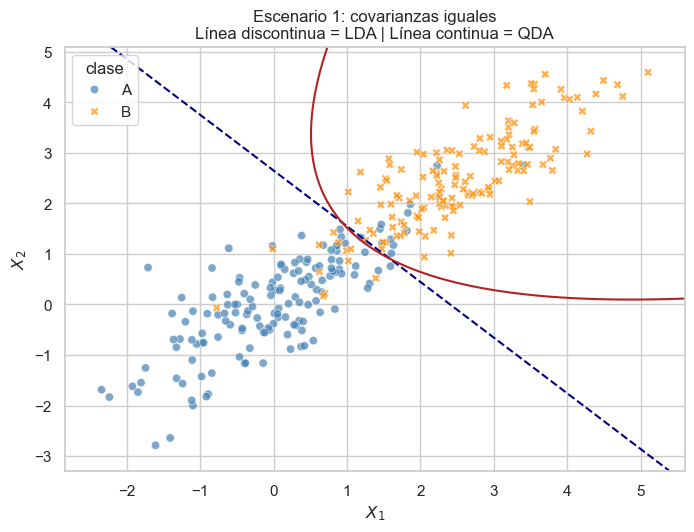

In [ ]:
np.random.seed(42)
n_sim = 150
Sigma_eq = np.array([[1, 0.8], [0.8, 1]])
mu_A = np.array([0, 0])
mu_B = np.array([2.5, 2.5])

Xa = np.random.multivariate_normal(mu_A, Sigma_eq, n_sim)
Xb = np.random.multivariate_normal(mu_B, Sigma_eq, n_sim)

dat1 = pd.DataFrame({
    'x1': np.concatenate([Xa[:, 0], Xb[:, 0]]),
    'x2': np.concatenate([Xa[:, 1], Xb[:, 1]]),
    'clase': ['A']*n_sim + ['B']*n_sim
})

mod_lda1 = LinearDiscriminantAnalysis().fit(dat1[['x1', 'x2']], dat1['clase'])
mod_qda1 = QuadraticDiscriminantAnalysis().fit(dat1[['x1', 'x2']], dat1['clase'])

# Rejilla de predicción
x1_min, x1_max = dat1['x1'].min() - 0.5, dat1['x1'].max() + 0.5
x2_min, x2_max = dat1['x2'].min() - 0.5, dat1['x2'].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200), np.linspace(x2_min, x2_max, 200))
grid1 = np.c_[xx1.ravel(), xx2.ravel()]

lda_prob1 = mod_lda1.predict_proba(grid1)[:, 1].reshape(xx1.shape)
qda_prob1 = mod_qda1.predict_proba(grid1)[:, 1].reshape(xx1.shape)

# Gráfico del Escenario 1
plt.figure()
sns.scatterplot(data=dat1, x='x1', y='x2', hue='clase', style='clase', palette=['steelblue', 'darkorange'], alpha=0.7)
plt.contour(xx1, xx2, lda_prob1, levels=[0.5], colors='navy', linestyles='dashed', linewidths=1.5)
plt.contour(xx1, xx2, qda_prob1, levels=[0.5], colors='firebrick', linestyles='solid', linewidths=1.5)
plt.title("Escenario 1: covarianzas iguales\nLínea discontinua = LDA | Línea continua = QDA")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.show()

Cuando las covarianzas son iguales las dos fronteras son casi idénticas y la frontera lineal (LDA) es óptima. QDA introduce curvatura innecesaria al estimar parámetros adicionales sin ganancia en sesgo.

### Escenario 2: Matrices de covarianza distintas (QDA óptimo)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


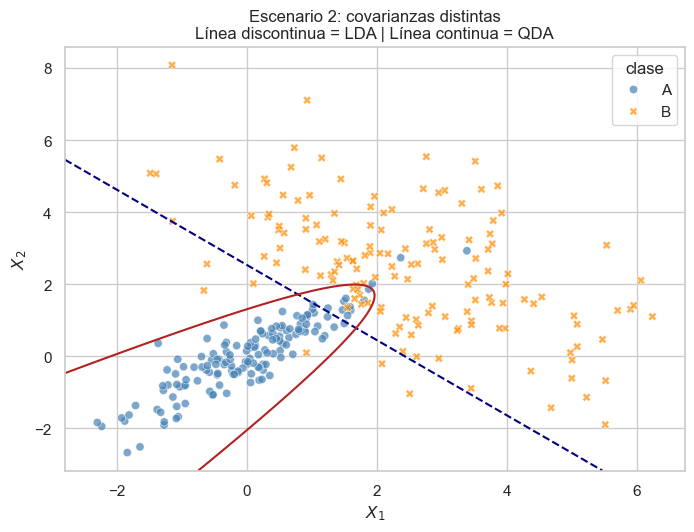

In [ ]:
np.random.seed(42)
Sigma_A = np.array([[1, 0.9], [0.9, 1]])
Sigma_B = np.array([[3, -1.5], [-1.5, 3]])

Xa2 = np.random.multivariate_normal(mu_A, Sigma_A, n_sim)
Xb2 = np.random.multivariate_normal(mu_B, Sigma_B, n_sim)
dat2 = pd.DataFrame({
    'x1': np.concatenate([Xa2[:, 0], Xb2[:, 0]]),
    'x2': np.concatenate([Xa2[:, 1], Xb2[:, 1]]),
    'clase': ['A']*n_sim + ['B']*n_sim
})

mod_lda2 = LinearDiscriminantAnalysis().fit(dat2[['x1', 'x2']], dat2['clase'])
mod_qda2 = QuadraticDiscriminantAnalysis().fit(dat2[['x1', 'x2']], dat2['clase'])

x1_min2, x1_max2 = dat2['x1'].min() - 0.5, dat2['x1'].max() + 0.5
x2_min2, x2_max2 = dat2['x2'].min() - 0.5, dat2['x2'].max() + 0.5
xx1_2, xx2_2 = np.meshgrid(np.linspace(x1_min2, x1_max2, 200), np.linspace(x2_min2, x2_max2, 200))
grid2 = np.c_[xx1_2.ravel(), xx2_2.ravel()]

lda_prob2 = mod_lda2.predict_proba(grid2)[:, 1].reshape(xx1_2.shape)
qda_prob2 = mod_qda2.predict_proba(grid2)[:, 1].reshape(xx1_2.shape)

# Gráfico del Escenario 2
plt.figure()
sns.scatterplot(data=dat2, x='x1', y='x2', hue='clase', style='clase', palette=['steelblue', 'darkorange'], alpha=0.7)
plt.contour(xx1_2, xx2_2, lda_prob2, levels=[0.5], colors='navy', linestyles='dashed', linewidths=1.5)
plt.contour(xx1_2, xx2_2, qda_prob2, levels=[0.5], colors='firebrick', linestyles='solid', linewidths=1.5)
plt.title("Escenario 2: covarianzas distintas\nLínea discontinua = LDA | Línea continua = QDA")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.show()

Con covarianzas distintas la frontera QDA (curva) sigue mejor la frontera de Bayes real, mientras que LDA introduce sesgo al asumir covarianzas iguales. La diferencia es especialmente visible en las regiones donde la dispersión del grupo B es mucho mayor.

## 3.4. QDA con datos reales: `Default`

In [ ]:
mod_qda_def = QuadraticDiscriminantAnalysis()
mod_qda_def.fit(X_train, y_train)
pred_qda_def = mod_qda_def.predict(X_test)

report_qda = classification_report(y_test, pred_qda_def, output_dict=True)

# Tabla comparativa LDA vs QDA
res = pd.DataFrame({
    'Método': ['LDA', 'QDA'],
    'Accuracy': [round(accuracy_score(y_test, pred_lda_def), 4), round(accuracy_score(y_test, pred_qda_def), 4)],
    'Sensibilidad': [round(report['Yes']['recall'], 4), round(report_qda['Yes']['recall'], 4)],
    'Especificidad': [round(report['No']['recall'], 4), round(report_qda['No']['recall'], 4)]
})

print("Tabla comparativa LDA vs QDA — Default (test 30%):")
display(res)

Tabla comparativa LDA vs QDA — Default (test 30%):


,Método,Accuracy,Sensibilidad,Especificidad
0,LDA,0.9733,0.2143,0.9990
1,QDA,0.9737,0.2551,0.9979


Ambos métodos obtienen accuracy similares. Sin embargo, QDA tiende a mejorar la sensibilidad al capturar mejor la forma de cada grupo, mientras que LDA puede ser preferible cuando el tamaño muestral es pequeño y la estimación de múltiples matrices de covarianza introduce varianza adicional.

---

# 4. Ejercicio Propuesto

**Ejercicio** Considere la base de datos `Smarket` de ISLR2, que contiene 1250 observaciones diarias del mercado bursátil estadounidense entre 2001 y 2005. La variable respuesta es `Direction` (`Up` / `Down`) en función de los retornos porcentuales rezagados `Lag1`, `Lag2`, `Lag3`, `Lag4`, `Lag5` y el volumen `Volume`.

a) Ajuste un modelo **Naive Bayes** (con marginales Gaussianas) utilizando como predictores `Lag1` y `Lag2`. Reporte la matriz de confusión y calcule Accuracy, Sensibilidad, Especificidad y AUC para los datos de entrenamiento (años 2001–2004) y prueba (año 2005).

b) Repita el ajuste con **LDA** y **QDA** usando los mismos predictores y conjunto de entrenamiento/prueba. Compare las tres métricas de desempeño e indique cuál método preferiría y por qué.

c) Grafique las fronteras de decisión de LDA y QDA en el espacio $(\texttt{Lag1}, \texttt{Lag2})$ e interprete visualmente la diferencia entre ambos métodos.

d) Usando validación cruzada 10-fold sobre el conjunto de entrenamiento, estime el error de predicción (Accuracy) de los tres métodos. ¿Cambia su conclusión respecto al literal (b)?

### Referencias
- Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani (2021) *An Introduction to Statistical Learning with Applications in R*, 2nd edition. Springer Series in Statistics.
- Trevor Hastie, Robert Tibshirani and Jerome Friedman (2008) *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. Springer Series in Statistics.